In [ ]:
# from opticalib.ground import osutils as osu

from astropy.io import fits

import matplotlib.pyplot as plt
# from matplotlib.ticker import AutoMinorLocator
import numpy as np
import os

(1e-06, 0.01)

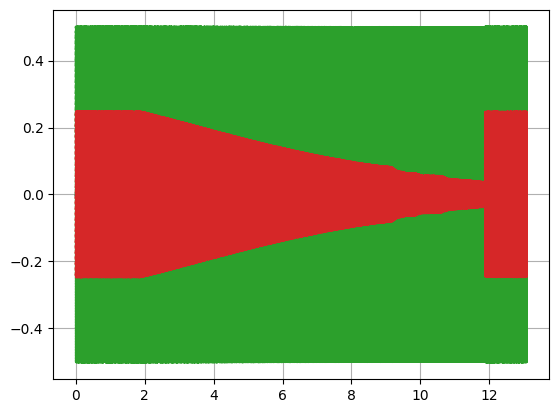

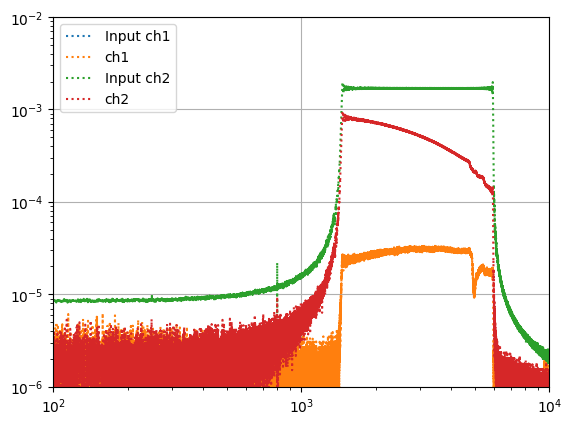

In [ ]:
webdaqpath = '/mnt/jumbo/SPLATT/WebDaqData'
freq = 51200

def read_fits(filename):
    hdu = fits.open(filename)
    data = hdu[0].data
    return data

def read_wbdq_data(tn,show:bool=False):
    filename = os.path.join(webdaqpath,tn)+'.fits'
    data = read_fits(filename) #osu.load_fits(filename)
    # raw_data = osu.load_fits(filename)
    # raw_data = raw_data.flatten()
    # data = np.zeros((4, len(raw_data)//4))
    # for i in range(4):
    #     data[i] = raw_data[i::4]
    tvec = np.arange(data.shape[1])/freq
    if show:
        plt.figure()
        plt.plot(tvec,data[1],':')
        plt.plot(tvec,data[0],':')
        plt.plot(tvec,data[2],':')
        plt.plot(tvec,data[3],':')
        plt.grid()
        # plt.xlim([0,0.001])
    return data, tvec

def get_spectrum(signal, dt=1, phase = False):
    spe = np.fft.rfft(signal, norm="ortho")
    nn = np.sqrt(len(spe))
    spe_mod = (np.abs(spe)) / nn
    freq = np.fft.rfftfreq(len(signal), d=dt)
    spe_mod[0] = 0
    if phase is True:
        spe_phi = np.angle(spe)
        return spe_mod, freq, spe_phi
    else:
        return spe_mod, freq
    
data,tvec = read_wbdq_data('20260226_090708',show=True)
tstart = 2
tend = 11.75
data = data[:,tvec>tstart]
tvec = tvec[tvec>tstart]
data = data[:,tvec<tend]
tvec = tvec[tvec<tend]

spe1,f = get_spectrum(data[0], dt=1/freq)
spe2,f = get_spectrum(data[1], dt=1/freq)
spe3,f = get_spectrum(data[2], dt=1/freq)
spe4,f = get_spectrum(data[3], dt=1/freq)
plt.figure()
plt.plot(f,spe1,':',label='Input ch1')
plt.plot(f,spe2,':',label='ch1')
plt.plot(f,spe3,':',label='Input ch2')
plt.plot(f,spe4,':',label='ch2')
plt.legend()
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.xlim([1e+2,1e+4])
plt.ylim([1e-6,1e-2])

Text(0.5, 1.0, 'PI transfer function')

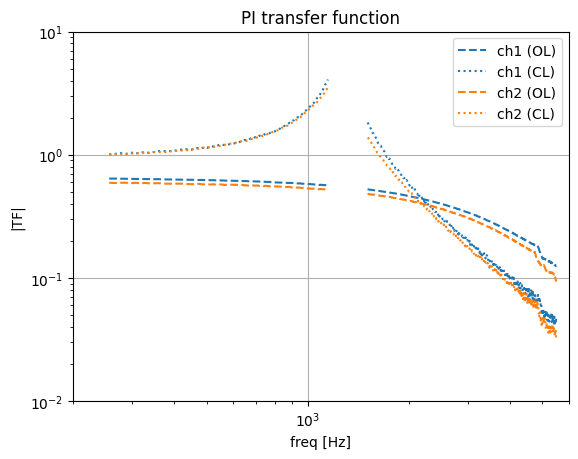

In [5]:
ch1_oltf = np.ones_like(spe1)*np.nan
ch2_oltf = np.ones_like(spe1)*np.nan
ch1_cltf = np.ones_like(spe1)*np.nan
ch2_cltf = np.ones_like(spe1)*np.nan

flow = (f>250)*(f<1150)
fhigh = (f>1500)*(f<5500)

# Ch1
data,tvec = read_wbdq_data('20260226_084237',show=False)
data = data[:,tvec>tstart]
tvec = tvec[tvec>tstart]
data = data[:,tvec<tend]
tvec = tvec[tvec<tend]
spe1,f = get_spectrum(data[0], dt=1/freq)
spe2,f = get_spectrum(data[1], dt=1/freq)
ch1_cltf[fhigh] = spe2[fhigh]/spe1[fhigh]
data,tvec = read_wbdq_data('20260226_084939',show=False)
data = data[:,tvec>tstart]
tvec = tvec[tvec>tstart]
data = data[:,tvec<tend]
tvec = tvec[tvec<tend]
spe1,f = get_spectrum(data[0], dt=1/freq)
spe2,f = get_spectrum(data[1], dt=1/freq)
ch1_cltf[flow] = spe2[flow]/spe1[flow]

data,tvec = read_wbdq_data('20260226_090857',show=False)
data = data[:,tvec>tstart]
tvec = tvec[tvec>tstart]
data = data[:,tvec<tend]
tvec = tvec[tvec<tend]
spe1,f = get_spectrum(data[0], dt=1/freq)
spe2,f = get_spectrum(data[1], dt=1/freq)
ch1_oltf[fhigh] = spe2[fhigh]/spe1[fhigh]
data,tvec = read_wbdq_data('20260226_090953',show=False)
data = data[:,tvec>tstart]
tvec = tvec[tvec>tstart]
data = data[:,tvec<tend]
tvec = tvec[tvec<tend]
spe1,f = get_spectrum(data[0], dt=1/freq)
spe2,f = get_spectrum(data[1], dt=1/freq)
ch1_oltf[flow] = spe2[flow]/spe1[flow]

# Ch2
data,tvec = read_wbdq_data('20260226_085224',show=False)
data = data[:,tvec>tstart]
tvec = tvec[tvec>tstart]
data = data[:,tvec<tend]
tvec = tvec[tvec<tend]
spe3,f = get_spectrum(data[2], dt=1/freq)
spe4,f = get_spectrum(data[3], dt=1/freq)
ch2_cltf[fhigh] = spe4[fhigh]/spe3[fhigh]
data,tvec = read_wbdq_data('20260226_085125',show=False)
data = data[:,tvec>tstart]
tvec = tvec[tvec>tstart]
data = data[:,tvec<tend]
tvec = tvec[tvec<tend]
spe3,f = get_spectrum(data[2], dt=1/freq)
spe4,f = get_spectrum(data[3], dt=1/freq)
ch2_cltf[flow] = spe4[flow]/spe3[flow]

data,tvec = read_wbdq_data('20260226_090708',show=False)
data = data[:,tvec>tstart]
tvec = tvec[tvec>tstart]
data = data[:,tvec<tend]
tvec = tvec[tvec<tend]
spe3,f = get_spectrum(data[2], dt=1/freq)
spe4,f = get_spectrum(data[3], dt=1/freq)
ch2_oltf[fhigh] = spe4[fhigh]/spe3[fhigh]
data,tvec = read_wbdq_data('20260226_090554',show=False)
data = data[:,tvec>tstart]
tvec = tvec[tvec>tstart]
data = data[:,tvec<tend]
tvec = tvec[tvec<tend]
spe3,f = get_spectrum(data[2], dt=1/freq)
spe4,f = get_spectrum(data[3], dt=1/freq)
ch2_oltf[flow] = spe4[flow]/spe3[flow]

dec = 100
plt.figure()
plt.plot(f[::dec],ch1_oltf[::dec],'--',c='C0',label='ch1 (OL)')
plt.plot(f[::dec],ch1_cltf[::dec],':',c='C0',label='ch1 (CL)')
plt.plot(f[::dec],ch2_oltf[::dec],'--',c='C1',label='ch2 (OL)')
plt.plot(f[::dec],ch2_cltf[::dec],':',c='C1',label='ch2 (CL)')
plt.legend()
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.xlim([200,6000])
plt.ylim([1e-2,10])
plt.xlabel('freq [Hz]')
plt.ylabel('|TF|')
plt.title('PI transfer function')